# 🔹 Section A — Datenaufbereitung der Messstellen

## 1. CSV einlesen und vorbereiten

In [144]:
import pandas as pd
import geopandas as gpd
from pyproj import Transformer

# Pfad anpassen:
path = "/Users/leonarddost/Downloads/sid_dav_verkehrszaehlung_miv_od2031_2025.csv"

# Relevante Spalten: 
cols = [
    "MSID", "MSName", "ZSID", "ZSName",
    "Achse", "HNr", "Hoehe",
    "EKoord", "NKoord", "Richtung",
    "MessungDatZeit", "AnzFahrzeuge", "AnzFahrzeugeStatus"
]

df = pd.read_csv(path, sep=",", usecols=lambda c: c in cols, dtype=str)

print(df.columns.tolist())



# Typen konvertieren
df["AnzFahrzeuge"] = pd.to_numeric(df["AnzFahrzeuge"], errors="coerce")
df["MessungDatZeit"] = pd.to_datetime(df["MessungDatZeit"], errors="coerce")
df["EKoord"] = pd.to_numeric(df["EKoord"], errors="coerce")
df["NKoord"] = pd.to_numeric(df["NKoord"], errors="coerce")

print(df.info())
print(df.head())


['MSID', 'MSName', 'ZSID', 'ZSName', 'Achse', 'HNr', 'Hoehe', 'EKoord', 'NKoord', 'Richtung', 'MessungDatZeit', 'AnzFahrzeuge', 'AnzFahrzeugeStatus']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490048 entries, 0 to 1490047
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   MSID                1490048 non-null  object        
 1   MSName              1490048 non-null  object        
 2   ZSID                1490048 non-null  object        
 3   ZSName              1490048 non-null  object        
 4   Achse               1490048 non-null  object        
 5   HNr                 1490048 non-null  object        
 6   Hoehe               1490048 non-null  object        
 7   EKoord              1490048 non-null  float64       
 8   NKoord              1490048 non-null  float64       
 9   Richtung            1490048 non-null  object        
 10  MessungDatZeit      1490048 non-null

## 2. Transformation und GeoFrame

In [145]:
import geopandas as gpd
from pyproj import Transformer

# LV95 → WGS84
transformer = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)
df["lon"], df["lat"] = transformer.transform(df["EKoord"].values, df["NKoord"].values)

# Bounds prüfen (Zürich ca. 8.4–8.6 / 47.3–47.45)
print(df["lon"].min(), df["lon"].max(), df["lat"].min(), df["lat"].max())

# GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)


8.472023731621112 8.598650982179922 47.33254743168517 47.427602732546816


<Axes: >

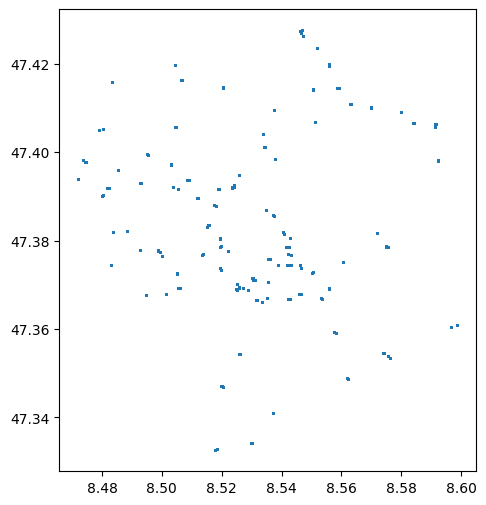

In [146]:
gdf.plot(markersize=1, figsize=(6,6))

## 3. Baseline-Aggregat pro Messstelle

In [147]:
agg = (
    gdf.groupby(["MSID", "Richtung"])
       .agg({
           "AnzFahrzeuge": "mean",
           "lon": "first",
           "lat": "first",
           "MSName": "first",
           "Achse": "first"
       })
       .reset_index()
       .rename(columns={"AnzFahrzeuge": "flow_mean"})
)

gdf_stations = gpd.GeoDataFrame(
    agg,
    geometry=gpd.points_from_xy(agg["lon"], agg["lat"]),
    crs="EPSG:4326"
)

print(gdf_stations.head())
print(gdf_stations["Richtung"].value_counts())


       MSID  Richtung   flow_mean       lon        lat     MSName  \
0  Z001M001  auswärts  279.867230  8.537068  47.341059  Unbekannt   
1  Z001M002  einwärts  348.793939  8.537112  47.341071  Unbekannt   
2  Z002M001  auswärts  224.688187  8.529921  47.334167  Unbekannt   
3  Z002M002  einwärts  280.505075  8.529980  47.334165  Unbekannt   
4  Z003M001  auswärts  153.751022  8.517891  47.332547  Unbekannt   

          Achse                  geometry  
0    Seestrasse  POINT (8.53707 47.34106)  
1    Seestrasse  POINT (8.53711 47.34107)  
2  Albisstrasse  POINT (8.52992 47.33417)  
3  Albisstrasse  POINT (8.52998 47.33417)  
4   Soodstrasse  POINT (8.51789 47.33255)  
Richtung
auswärts             43
einwärts             42
Bucheggplatz          6
See                   6
Oerlikon              5
                     ..
Hegibachplatz         1
Zollikon              1
Stauffacherplatz      1
Schaffhauserplatz     1
Hönggerberg           1
Name: count, Length: 77, dtype: int64


### Richtungswerte klassifizieren

In [148]:
import numpy as np

def classify_direction(x):
    x = x.strip().lower()
    if "einwärts" in x:
        return "in"
    elif "auswärts" in x:
        return "out"
    else:
        return "label"  # z.B. "Oerlikon", "Bucheggplatz", etc.

gdf_stations["Richtung_typ"] = gdf_stations["Richtung"].apply(classify_direction)
print(gdf_stations["Richtung_typ"].value_counts())


Richtung_typ
label    126
out       43
in        43
Name: count, dtype: int64


In [149]:
print(gdf_stations.loc[gdf_stations["Richtung_typ"] == "label", "Richtung"].value_counts().head(30))


Richtung
Bucheggplatz            6
See                     6
Heimplatz               5
Affoltern               5
Oerlikon                5
Birmensdorferstrasse    4
Hohlstrasse             4
Hardbrücke              3
Hubertus                3
Seebahnstrasse          3
Altstetten              3
Sihlhölzli              2
Höngg                   2
Sihlporte               2
Klusplatz               2
Central                 2
Manessestrasse          2
Albisriederplatz        2
Hauptbahnhof            2
Stauffacher             2
Badenerstrasse          2
Hardplatz               2
Schwamendingen          2
Bellevue                2
Schimmelstrasse         2
Bahnhof                 2
Zoo                     2
Talstrasse              1
Forchstrasse            1
Pfingstweidstrasse      1
Name: count, dtype: int64


# Section B - Seeds & Snapping (mit heuristischen Richtungen)

In [150]:
import math
import osmnx as ox
import geopandas as gpd

## 1. Heuristische Bearing-Zuordnung für Labels
Wir erzeugen zuerst eine Mapping-Tabelle mit den wichtigsten Ortsnamen aus deinen Labels und schätzen daraus geografische Richtungen in Grad (Bearing, 0 = Nord, 90 = Ost, 180 = Süd, 270 = West).

In [151]:
# === Finales heuristisches Mapping Zürich (vollständig, alle bekannten Labels) ===
label_bearings = {
    # Norden / Nordosten
    "oerlikon": 45, "affoltern": 45, "schwamendingen": 45,
    "bucheggplatz": 0, "heimplatz": 15, "klusplatz": 20,
    "zoo": 30, "hoengg": 330, "hoenggerberg": 330, "zollikon": 80,
    "wipkingerplatz": 350, "limmatplatz": 0, "schaffhauserplatz": 10,
    "milchbuck": 20, "milchbucktunnel": 20, "universitaet": 30,
    "hegibachplatz": 40, "kreuzplatz": 40, "winterthur": 45,
    "zehntenhausplatz": 350,

    # Osten
    "vorderberg": 90,

    # Süden / Südosten (See / City)
    "see": 135, "bellevue": 135, "bellvue": 135,
    "sihlporte": 160, "central": 150, "stauffacher": 160,
    "hauptbahnhof": 140, "bahnhof": 140,
    "talstrasse": 150, "manessestrasse": 170,
    "birmensdorferstrasse": 190, "soodstrasse": 190,
    "sihlhoelzli": 180, "forchstrasse": 110, "hubertus": 180,
    "buerkliplatz": 150, "loewe": 150, "loewenplatz": 150,
    "rudolf": 150, "brun": 150, "rudolf-brun-bruecke": 150,
    "brudolf-brun-bruecke": 150, "enge": 170,
    "suedstrasse": 180, "selnau": 170, 
    "nord": 0, "muehlegasse": 160, 
    "chur": 180,

    # Westen / Südwesten
    "albisriederplatz": 270, "altstetten": 260, "altstetter": 260,
    "badenerstrasse": 260, "hardplatz": 260, "hardbruecke": 260,
    "hohlstrasse": 260, "pfingstweidstrasse": 280,
    "letzigrund": 260, "letzigraben": 260,
    "autobahn": 250, "bernerstrasse": 260,
    "helvetiaplatz": 250, "uetlibergtunnel": 210,
    "allmend": 200, "luggweg": 260, 
    "altstetter-/luggwegstrasse": 260, "a3": 250,
    "schimmelstrasse": 260,

    # Südwest / West-Südwest
    "triemli": 210, "utogrund": 230, "albis": 220,

    # Sonderfälle / zusammengesetzte
    "höngg": 330, "höngg/europabrücke": 330,
    "escher wyss": 350, "escher wyss platz": 350,
    "walcheplatz": 10, "mühlegasse": 160,
    "bleicherweg": 160
}

# === Funktion zur Zuordnung (mit Umlaut-Handling) ===
def get_label_bearing(label):
    label = str(label).lower().strip()
    label = label.replace("ö", "oe").replace("ü", "ue").replace("ä", "ae")
    for key, bearing in label_bearings.items():
        if key in label:
            return bearing
    return None


Dann fügen wir für alle Messstellen eine Spalte bearing_seed hinzu:

In [152]:
# Stadtzentrum (ungefähr Paradeplatz)
center_lon, center_lat = 8.5390, 47.3724

def bearing_to_center(row):
    dx = center_lon - row["lon"]
    dy = center_lat - row["lat"]
    angle = math.degrees(math.atan2(dx, dy))
    if angle < 0:
        angle += 360
    return angle

def bearing_from_type(row):
    if row["Richtung_typ"] == "in":
        return bearing_to_center(row)
    elif row["Richtung_typ"] == "out":
        b = bearing_to_center(row)
        return (b + 180) % 360
    else:
        return get_label_bearing(row["Richtung"])

gdf_stations["bearing_seed"] = gdf_stations.apply(bearing_from_type, axis=1)


In [153]:
mask = gdf_stations["bearing_seed"].isna()
gdf_stations["bearing_seed"] = gdf_stations["bearing_seed"].astype(float)
gdf_stations.loc[mask, "bearing_seed"] = gdf_stations.loc[mask, "Richtung"].apply(get_label_bearing)

/var/folders/5h/7hhdw_3j1bz_15_wtp0jmb_80000gn/T/ipykernel_31304/2390646882.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gdf_stations.loc[mask, "bearing_seed"] = gdf_stations.loc[mask, "Richtung"].apply(get_label_bearing)


In [154]:
print("Anzahl NaN-Bearings:", gdf_stations["bearing_seed"].isna().sum())
print(gdf_stations.loc[gdf_stations["bearing_seed"].isna(), ["Richtung"]].head(17))

Anzahl NaN-Bearings: 0
Empty DataFrame
Columns: [Richtung]
Index: []


In [155]:
import pandas as pd
import numpy as np

print("=== 1. Überblick ===")
print("Anzahl Messstellen:", len(gdf_stations))
print("NaN bearing_seed:", gdf_stations['bearing_seed'].isna().sum())
print("NaN Koordinaten:", gdf_stations[['lon','lat']].isna().any(axis=1).sum())
print("NaN flow_mean:", gdf_stations['flow_mean'].isna().sum())

print("\n=== 2. Wertebereiche ===")
print(gdf_stations[['flow_mean','bearing_seed']].describe())

print("\n=== 3. Richtungstyp-Verteilung ===")
print(gdf_stations['Richtung_typ'].value_counts())

print("\n=== 4. Stichprobe ===")
print(gdf_stations.sample(5, random_state=42)[
    ["MSID","Richtung","Richtung_typ","bearing_seed","flow_mean","Achse"]
])

print("\n=== 5. Plausibilitäts-Check Bearings ===")
print("Min bearing:", gdf_stations['bearing_seed'].min(),
      "Max bearing:", gdf_stations['bearing_seed'].max())
print("Außerhalb 0–360°:", ((gdf_stations['bearing_seed']<0) | (gdf_stations['bearing_seed']>360)).sum())


=== 1. Überblick ===
Anzahl Messstellen: 212
NaN bearing_seed: 0
NaN Koordinaten: 0
NaN flow_mean: 0

=== 2. Wertebereiche ===
         flow_mean
count   212.000000
mean    307.162890
std     256.522615
min       0.000000
25%     148.051688
50%     230.234348
75%     394.143645
max    1708.787354

=== 3. Richtungstyp-Verteilung ===
Richtung_typ
label    126
out       43
in        43
Name: count, dtype: int64

=== 4. Stichprobe ===
         MSID     Richtung Richtung_typ bearing_seed   flow_mean  \
30   Z016M003     auswärts          out    57.580511  462.078580   
173  Z091M001   Talstrasse        label        150.0  309.433901   
140  Z073M002  Stauffacher        label        160.0  146.900268   
75   Z040M001  Hohlstrasse        label        260.0  626.935255   
60   Z032M001     Oerlikon        label         45.0  250.982538   

                 Achse  
30    Ueberlandstrasse  
173   Dreikönigstrasse  
140  Stauffacherbrücke  
75      Seebahnstrasse  
60    Binzmühlestrasse  

=== 5

## 2. OSM Strassennetz laden

In [25]:
# Straßennetz Zürich
G = ox.graph_from_place("Zürich, Switzerland", network_type="drive")

# Bearings hinzufügen
G = ox.bearing.add_edge_bearings(G)

# Schnellcheck
u, v, k, data = next(iter(G.edges(keys=True, data=True)))
print("Sample edge attrs:", data)


Sample edge attrs: {'osmid': [1443804326, 9386989, 284193360, 438520592, 134223699, 438521946], 'highway': ['primary', 'motorway'], 'lanes': ['2', '3'], 'maxspeed': '60', 'oneway': True, 'ref': ['1;3', 'A1H'], 'reversed': False, 'length': np.float64(830.2203887939971), 'name': 'Bernerstrasse Süd', 'geometry': <LINESTRING (8.485 47.395, 8.488 47.394, 8.489 47.394, 8.49 47.394, 8.491 47...>, 'bearing': np.float64(104.08027628730906)}


## 3. Snapping / Seed-Erzeugung

In [157]:
import osmnx as ox
import numpy as np
from shapely.geometry import Point

# Sicherheitscheck: gleiche CRS
assert gdf_stations.crs.to_string() == "EPSG:4326", "gdf_stations muss in WGS84 sein"


### nächste Kanten finden

In [158]:
# Nächste Kante (Edge) für jede Messstelle bestimmen
edges, dists = ox.distance.nearest_edges(
    G,
    X=gdf_stations["lon"].to_numpy(),
    Y=gdf_stations["lat"].to_numpy(),
    return_dist=True
)

gdf_stations["edge_key"] = edges
gdf_stations["snap_dist_m"] = dists


### Qualität Prüfen

In [159]:
# quality check
print("Gematchte Punkte:", len(gdf_stations))
print("Ø Snap-Distanz (m):", np.nanmean(gdf_stations["snap_dist_m"]))
print("Punkte >30 m vom Straßennetz entfernt:", (gdf_stations["snap_dist_m"] > 30).sum())


Gematchte Punkte: 212
Ø Snap-Distanz (m): 4.575039547566471e-05
Punkte >30 m vom Straßennetz entfernt: 0


### Bearing-Abweichung berechnen

In [160]:
# Hole Bearing der zugeordneten Kante aus dem Graphen
bearings = []
for (u, v, key) in gdf_stations["edge_key"]:
    data = G.get_edge_data(u, v, key)
    bearings.append(data.get("bearing", np.nan))

gdf_stations["bearing_edge"] = bearings

# Differenz zwischen Messstellenrichtung und Straßenrichtung
def bearing_diff(b1, b2):
    if np.isnan(b1) or np.isnan(b2):
        return np.nan
    diff = abs(b1 - b2) % 360
    return min(diff, 360 - diff)

gdf_stations["bearing_diff"] = gdf_stations.apply(
    lambda r: bearing_diff(r["bearing_seed"], r["bearing_edge"]), axis=1
)


### Ergebnis prüfen

In [161]:
print("Ø Bearing-Abweichung (°):", np.nanmean(gdf_stations["bearing_diff"]))
print("Median Bearing-Abweichung (°):", np.nanmedian(gdf_stations["bearing_diff"]))

print("\nBeispiel-Seeds:")
print(gdf_stations[["MSID","Richtung","Richtung_typ","bearing_seed",
                    "bearing_edge","bearing_diff","snap_dist_m"]].head(10))


Ø Bearing-Abweichung (°): 76.84433468047725
Median Bearing-Abweichung (°): 60.26192576535899

Beispiel-Seeds:
       MSID  Richtung Richtung_typ bearing_seed  bearing_edge  bearing_diff  \
0  Z001M001  auswärts          out   183.527386    158.988516     24.538870   
1  Z001M002  einwärts           in     3.448993    338.990707     24.458286   
2  Z002M001  auswärts          out   193.357563    181.799060     11.558503   
3  Z002M002  einwärts           in    13.274529    181.799060    168.524532   
4  Z003M001  auswärts          out   207.908956     30.848762    177.060194   
5  Z003M002  einwärts           in    27.607956    197.507332    169.899377   
6  Z004M001  auswärts          out   264.069294    216.117476     47.951818   
7  Z004M002  einwärts           in    83.917438     82.169556      1.747882   
8  Z005M001  auswärts          out    272.15093     49.534695    137.383765   
9  Z005M002  einwärts           in    92.097204    229.535014    137.437810   

   snap_dist_m  
0  

### Finales GeoDataFrame gdf_seeds

In [162]:
import geopandas as gpd

gdf_seeds = gpd.GeoDataFrame(
    gdf_stations[
        ["MSID","Richtung","Richtung_typ","flow_mean",
         "bearing_seed","bearing_edge","bearing_diff",
         "edge_key","snap_dist_m","geometry"]
    ].copy(),
    crs="EPSG:4326"
)

print("Seeds gesamt:", len(gdf_seeds))


Seeds gesamt: 212


### Karte zur Kontrolle

In [163]:
import folium

m = folium.Map(location=[47.37, 8.54], zoom_start=12)

for _, row in gdf_seeds.iterrows():
    color = (
        "blue" if row["Richtung_typ"] == "in"
        else "red" if row["Richtung_typ"] == "out"
        else "orange"
    )
    folium.CircleMarker(
        location=(row.geometry.y, row.geometry.x),
        radius=4,
        color=color,
        popup=f"{row['MSID']} | {row['Richtung']} | Δ={row['bearing_diff']:.1f}° | {row['snap_dist_m']:.1f} m"
    ).add_to(m)

m.save("zuerich_seeds_map.html")
print("Interaktive Karte: 'zuerich_seeds_map.html'")


Interaktive Karte: 'zuerich_seeds_map.html'


# Section C1 - Fluss-Propagation (Grundstruktur)

## Grundidee
Jeder Seed erzeugt eine Art „Welle“, die entlang der OSM-Kanten fließt.
An jeder Kante wird der Fluss weitergegeben, bis:

- die maximale Distanz (z. B. 3 km) erreicht ist, oder
- der Fluss zu stark gedämpft ist (< Schwellwert).

## Vorbereitung

In [164]:
import networkx as nx
import math

# Parameter für die Propagation
MAX_DISTANCE_M = 3000   # maximale Ausbreitungsdistanz in Metern
DECAY_FACTOR = 0.95     # Dämpfung pro 100 m
MIN_FLOW = 5            # minimaler Flusswert, unter dem nicht weiter propagiert wird


## Hilfsfunktionen

### a) Dämpfung berechnen

In [165]:
def damp_flow(flow_value, distance_m):
    """Dämpfe den Fluss abhängig von der Distanz."""
    decay_steps = distance_m / 100
    return flow_value * (DECAY_FACTOR ** decay_steps)


### b) Bearing-Differenz berechnen
(damit der Fluss nicht gegen die Fahrtrichtung läuft)

In [166]:
def bearing_diff(b1, b2):
    if math.isnan(b1) or math.isnan(b2):
        return 180
    diff = abs(b1 - b2) % 360
    return min(diff, 360 - diff)

## Fluss entlang des Netzwerks ausbreiten
Wir gehen nun Seed für Seed durch.
Jeder Seed startet auf einer Kante (u, v) und breitet sich entlang des Graphen aus.
Dazu nutzen wir networkx.single_source_dijkstra, das alle Pfade ab einem Startknoten mit Distanz liefert.

In [167]:
flows = []

for idx, seed in gdf_seeds.iterrows():
    u, v, k = seed["edge_key"]
    start_flow = seed["flow_mean"]
    seed_bearing = seed["bearing_seed"]

    # Seed soll entlang der Kante mit passender Richtung starten:
    if bearing_diff(seed_bearing, G[u][v][k].get("bearing", 180)) > 90:
        # Falls der Seed entgegen der Fahrtrichtung liegt → Richtung umdrehen
        u, v = v, u

    # Dijkstra: alle erreichbaren Knoten bis MAX_DISTANCE_M
    lengths = nx.single_source_dijkstra_path_length(G, u, cutoff=MAX_DISTANCE_M, weight="length")

    for target, dist_m in lengths.items():
        if dist_m == 0:
            continue

        flow_value = damp_flow(start_flow, dist_m)
        if flow_value < MIN_FLOW:
            continue

        flows.append({
            "MSID": seed["MSID"],
            "start_node": u,
            "end_node": target,
            "distance_m": dist_m,
            "flow_value": flow_value,
            "bearing_seed": seed_bearing
        })


## Ergebnisse in DataFrame umwandeln

In [168]:
import pandas as pd

df_flows = pd.DataFrame(flows)
print("Berechnete Flusspfade:", len(df_flows))
print(df_flows.head())


Berechnete Flusspfade: 205928
       MSID  start_node    end_node  distance_m  flow_value  bearing_seed
0  Z001M001    74926632  5254058386   24.995913  276.301894    183.527386
1  Z001M001    74926632    34403221   30.524729  275.519436    183.527386
2  Z001M001    74926632   262971442   59.263752  271.487740    183.527386
3  Z001M001    74926632  5254058388   90.613563  267.157035    183.527386
4  Z001M001    74926632    74925225  216.522020  250.448682    183.527386


## Qualitätskontrolle

In [169]:
print(df_flows["flow_value"].describe())
print("Max Distanz (m):", df_flows["distance_m"].max())


count    205928.000000
mean        126.600859
std         109.791602
min           5.002871
25%          55.002544
50%          93.197190
75%         159.935844
max        1516.978041
Name: flow_value, dtype: float64
Max Distanz (m): 2999.999882457955


## Testplot der Dämpfung

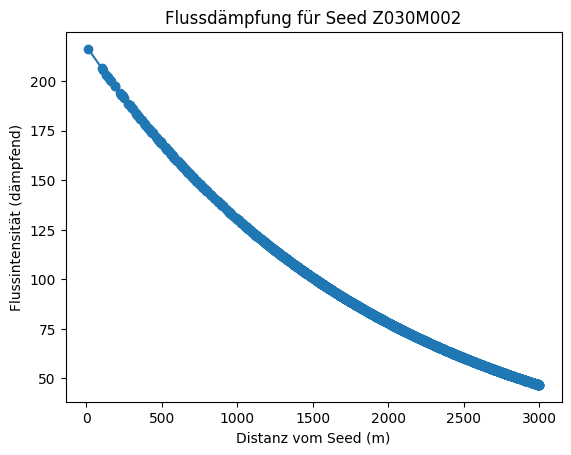

In [170]:
# Seed mit den meisten propagierten Knoten
best_seed_id = df_flows["MSID"].value_counts().idxmax()
sample_flows = df_flows[df_flows["MSID"] == best_seed_id]

import matplotlib.pyplot as plt

plt.plot(sample_flows["distance_m"], sample_flows["flow_value"], marker="o")
plt.xlabel("Distanz vom Seed (m)")
plt.ylabel("Flussintensität (dämpfend)")
plt.title(f"Flussdämpfung für Seed {best_seed_id}")
plt.show()


# Section C2 - Richtungsgewichtung & Kreuzungsaufteilung
Ziel:
Wenn sich der Fluss an einer Kreuzung aufteilt, soll er nicht einfach gleichmäßig in alle Richtungen laufen,
sondern bevorzugt in jene Kanten, die dem ursprünglichen Bearing des Flusses am nächsten liegen.

## Vorbereitung

In [171]:
from tqdm.notebook import tqdm
import networkx as nx
import numpy as np
import math
import pandas as pd

MAX_DISTANCE_M = 5000      # maximale Ausbreitung
DECAY_FACTOR = 0.985        # Dämpfung pro 100 m
MIN_FLOW = 5               # Stoppschwelle
MAX_BEARING_DIFF = 135      # nur Richtungen innerhalb ±90°
BEARING_WEIGHT_EXP = 1.0   # exponentielle Richtungsgewichtung
MIN_EDGE_SHARE = 0.01      # min. Anteil

def damp_flow(flow_value, distance_m):
    """Exponentielle Dämpfung mit Distanz."""
    decay_steps = distance_m / 100
    return flow_value * (DECAY_FACTOR ** decay_steps)

def bearing_diff(b1, b2):
    if np.isnan(b1) or np.isnan(b2):
        return 180
    diff = abs(b1 - b2) % 360
    return min(diff, 360 - diff)

def direction_weight(seed_bearing, edge_bearing):
    diff = bearing_diff(seed_bearing, edge_bearing)
    if diff > MAX_BEARING_DIFF:
        return 0.0
    w = (1 - diff / MAX_BEARING_DIFF) ** BEARING_WEIGHT_EXP
    return max(w, 0.0)


## Modifizierte Propagation mit Richtungsgewichtung
Wir erweitern die Schleife aus C.1:
Beim Weitergeben des Flusses an Nachbarkanten wird jetzt ein Richtungsgewicht berücksichtigt.

**💡 Ergebnis:
An Kreuzungen mit vielen Abzweigungen wird der Fluss automatisch bevorzugt in Kanten mit ähnlicher Richtung weitergegeben.**

In [172]:
flows_dir = []

for idx, seed in tqdm(gdf_seeds.iterrows(), total=len(gdf_seeds), desc="Propagating traffic flows"):
    u, v, k = seed["edge_key"]
    start_flow = seed["flow_mean"]
    seed_bearing = seed["bearing_seed"]

    # Prüfe, ob Seed in Fahrtrichtung liegt
    edge_bearing = G[u][v][k].get("bearing", 180)
    if bearing_diff(seed_bearing, edge_bearing) > 90:
        u, v = v, u

    # Dijkstra liefert erreichbare Knoten bis cutoff
    lengths = nx.single_source_dijkstra_path_length(G, u, cutoff=MAX_DISTANCE_M, weight="length")

    for target, dist_m in lengths.items():
        if dist_m == 0:
            continue

        flow_value = damp_flow(start_flow, dist_m)
        if flow_value < MIN_FLOW:
            continue

        # für alle Kanten ab Zielknoten
        for u2, v2, k2, data in G.edges(target, data=True, keys=True):
            edge_bearing = data.get("bearing", np.nan)
            w = direction_weight(seed_bearing, edge_bearing)
            if w < MIN_EDGE_SHARE:
                continue

            flows_dir.append({
                "MSID": seed["MSID"],
                "start_node": u,
                "end_node": target,
                "distance_m": dist_m,
                "flow_value": flow_value * w,
                "bearing_seed": seed_bearing,
                "bearing_edge": edge_bearing,
                "weight": w
            })


Propagating traffic flows:   0%|          | 0/212 [00:00<?, ?it/s]

## Auswertung

In [173]:
df_flows_dir = pd.DataFrame(flows_dir)
print("Propagierte Segmente:", len(df_flows_dir))
print(df_flows_dir[["flow_value","weight","distance_m"]].describe())

Propagierte Segmente: 809239
          flow_value         weight     distance_m
count  809239.000000  809239.000000  809239.000000
mean      104.862862       0.507563    3132.527189
std       111.301588       0.286210    1196.113335
min         0.073073       0.010001       4.358655
25%        31.311374       0.257191    2229.696540
50%        69.919806       0.514020    3252.761455
75%       136.507601       0.754325    4146.560089
max      1331.534306       1.000000    4999.970571


### Schnelle Visualisierung des gerichteten Flusses (C.2-Resultate)

In [174]:
df_plot = df_flows_dir.copy()
df_plot["flow_norm"] = df_plot["flow_value"] / df_plot["flow_value"].max()


In [175]:
import geopandas as gpd
from shapely.geometry import LineString

lines = []

for _, row in df_plot.sample(5000, random_state=42).iterrows():  # nur 5000 zum Testen
    try:
        u_geom = Point(G.nodes[row["start_node"]]["x"], G.nodes[row["start_node"]]["y"])
        v_geom = Point(G.nodes[row["end_node"]]["x"], G.nodes[row["end_node"]]["y"])
        line = LineString([u_geom, v_geom])
        lines.append({
            "MSID": row["MSID"],
            "flow_value": row["flow_value"],
            "flow_norm": row["flow_norm"],
            "geometry": line
        })
    except Exception:
        continue

gdf_lines = gpd.GeoDataFrame(lines, crs="EPSG:4326")
print("Linien für Visualisierung:", len(gdf_lines))


Linien für Visualisierung: 5000


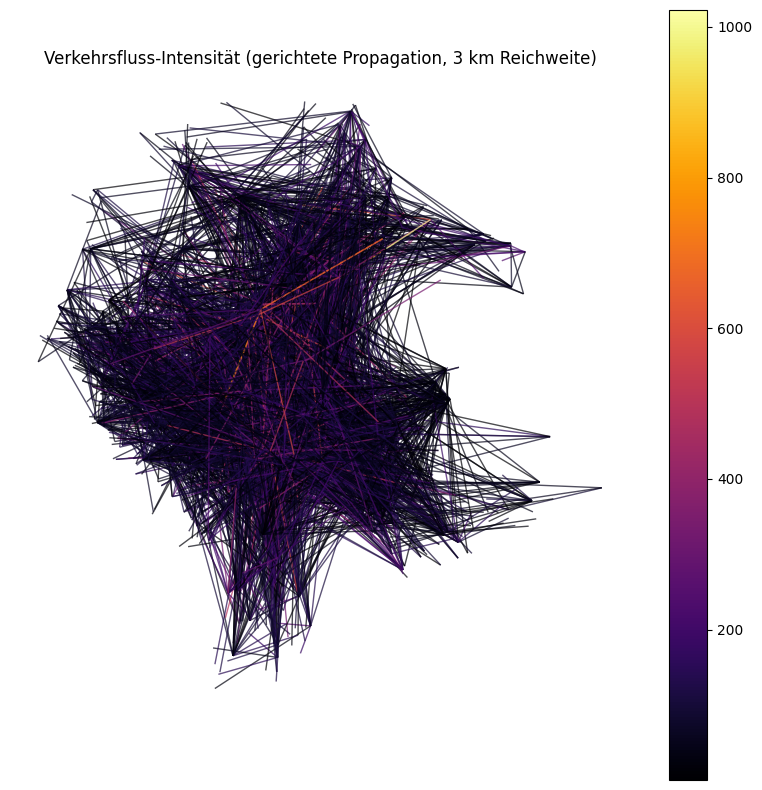

In [176]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf_lines.plot(
    ax=ax,
    linewidth=1,
    alpha=0.7,
    column="flow_value",
    cmap="inferno",
    legend=True
)
ax.set_title("Verkehrsfluss-Intensität (gerichtete Propagation, 3 km Reichweite)")
ax.set_axis_off()
plt.show()


In [92]:
import folium
from matplotlib import pyplot as plt

# Karte initialisieren (Zürich Zentrum)
m = folium.Map(location=[47.37, 8.54], zoom_start=12, tiles="cartodbpositron")

# ==== 1️⃣ Flusslinien (aus Propagation) ====
for _, row in gdf_lines.sample(3000, random_state=1).iterrows():
    color = plt.cm.inferno(row["flow_norm"])
    color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    folium.PolyLine(
        locations=[(y, x) for x, y in row["geometry"].coords],
        color=color,
        weight=2,
        opacity=0.6
    ).add_to(m)

# ==== 2️⃣ Messstationen (Seeds) ====
for _, row in gdf_seeds.iterrows():
    # Farbe nach Richtungstyp
    color = (
        "blue" if row["Richtung_typ"] == "in"
        else "red" if row["Richtung_typ"] == "out"
        else "orange"
    )

    # Popup mit Info
    popup_text = (
        f"<b>{row['MSID']}</b><br>"
        f"{row['Richtung']}<br>"
        f"Flow: {row['flow_mean']:.1f}<br>"
        f"Bearing: {row['bearing_seed']:.1f}°"
    )

    # Marker mit Richtungspfeil (kleine Linie als Richtung)
    p_lat, p_lon = row.geometry.y, row.geometry.x
    arrow_len = 0.001  # etwa 100 m
    dx = arrow_len * math.sin(math.radians(row["bearing_seed"]))
    dy = arrow_len * math.cos(math.radians(row["bearing_seed"]))
    line = [(p_lat, p_lon), (p_lat + dy, p_lon + dx)]

    # Marker + Pfeil-Linie
    folium.CircleMarker(
        location=(p_lat, p_lon),
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        popup=popup_text
    ).add_to(m)
    folium.PolyLine(
        locations=line,
        color=color,
        weight=2,
        opacity=0.9
    ).add_to(m)

# Karte speichern
m.save("zuerich_flow_with_stations.html")
print("Karte gespeichert als 'zuerich_flow_with_stations.html'")


Karte gespeichert als 'zuerich_flow_with_stations.html'


In [93]:
import folium
import math
import geopandas as gpd
from shapely.geometry import Point, LineString
from matplotlib import pyplot as plt

# ========================
# 1️⃣ Flusslinien entlang realer Straßen erzeugen
# ========================

lines = []

for _, row in df_flows_dir.sample(5000, random_state=42).iterrows():  # sample für Performance
    try:
        u, v = row["start_node"], row["end_node"]

        # Hole echte OSM-Kantengeometrie
        data = G.get_edge_data(u, v)
        if data:
            edge = list(data.values())[0]  # erste Variante nehmen (key=0)
            geom = edge.get("geometry")

            # Fallback auf gerade Linie, falls keine Geometrie gespeichert
            if geom is None:
                u_geom = Point(G.nodes[u]["x"], G.nodes[u]["y"])
                v_geom = Point(G.nodes[v]["x"], G.nodes[v]["y"])
                geom = LineString([u_geom, v_geom])
        else:
            u_geom = Point(G.nodes[u]["x"], G.nodes[u]["y"])
            v_geom = Point(G.nodes[v]["x"], G.nodes[v]["y"])
            geom = LineString([u_geom, v_geom])

        lines.append({
            "MSID": row["MSID"],
            "flow_value": row["flow_value"],
            "geometry": geom
        })

    except Exception:
        continue

# GeoDataFrame mit Linien
gdf_lines = gpd.GeoDataFrame(lines, crs="EPSG:4326")
gdf_lines["flow_norm"] = gdf_lines["flow_value"] / gdf_lines["flow_value"].max()

print("Linien entlang der Straßen:", len(gdf_lines))


# ========================
# 2️⃣ Karte initialisieren
# ========================

m = folium.Map(location=[47.37, 8.54], zoom_start=12, tiles="cartodbpositron")


# ========================
# 3️⃣ Flusslinien plotten
# ========================

for _, row in gdf_lines.sample(3000, random_state=1).iterrows():
    color = plt.cm.inferno(row["flow_norm"])
    color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    folium.PolyLine(
        locations=[(y, x) for x, y in row["geometry"].coords],
        color=color,
        weight=2.5 * row["flow_norm"] + 0.3,  # dickere Linien bei stärkerem Fluss
        opacity=0.7
    ).add_to(m)


# ========================
# 4️⃣ Messstationen mit Richtungspfeilen
# ========================

for _, row in gdf_seeds.iterrows():
    # Farbe nach Richtungstyp
    color = (
        "blue" if row["Richtung_typ"] == "in"
        else "red" if row["Richtung_typ"] == "out"
        else "orange"
    )

    # Popup
    popup_text = (
        f"<b>{row['MSID']}</b><br>"
        f"{row['Richtung']}<br>"
        f"Flow: {row['flow_mean']:.1f}<br>"
        f"Bearing: {row['bearing_seed']:.1f}°"
    )

    # Position und Richtungspfeil
    p_lat, p_lon = row.geometry.y, row.geometry.x
    arrow_len = 0.001  # etwa 100 m auf der Karte
    dx = arrow_len * math.sin(math.radians(row["bearing_seed"]))
    dy = arrow_len * math.cos(math.radians(row["bearing_seed"]))
    line = [(p_lat, p_lon), (p_lat + dy, p_lon + dx)]

    # Marker
    folium.CircleMarker(
        location=(p_lat, p_lon),
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        popup=popup_text
    ).add_to(m)

    # Richtungslinie (kleiner Pfeil)
    folium.PolyLine(
        locations=line,
        color=color,
        weight=2,
        opacity=0.9
    ).add_to(m)


# ========================
# 5️⃣ Karte speichern
# ========================

m.save("zuerich_flow_with_streets.html")
print("Karte gespeichert als 'zuerich_flow_with_streets.html'")


Linien entlang der Straßen: 5000
Karte gespeichert als 'zuerich_flow_with_streets.html'


# Section C3 – Aggregation & Visualisierung des Verkehrsflusses pro Straße
Hier verdichten wir all die einzelnen propagierten Flüsse (df_flows_dir) auf Straßenebene,
sodass du sie als Heatmap oder gerichtete Linien sehen und analysieren kannst.

In [101]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
from matplotlib import pyplot as plt

## Aggregierte Flüsse pro OSM-Kante

In [120]:
# ========================
# 1️⃣ Aggregation pro Kante
# ========================

df_edge_flow = (
    df_flows_dir
    .groupby(["start_node", "end_node"])
    .agg(
        total_flow=("flow_value", "sum"),
        mean_weight=("weight", "mean"),
        n_sources=("MSID", "nunique")
    )
    .reset_index()
)

print("Aggregierte Straßenkanten:", len(df_edge_flow))

Aggregierte Straßenkanten: 122252


## OSM-Edges aus dem Graph extrahieren

In [121]:
# ========================
# 2️⃣ OSM-Kanten extrahieren
# ========================

edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)
edges_gdf = edges_gdf.reset_index()[["u", "v", "key", "geometry", "name", "length", "bearing"]]

# gleiche Datentypen sicherstellen
df_edge_flow["start_node"] = df_edge_flow["start_node"].astype(int)
df_edge_flow["end_node"] = df_edge_flow["end_node"].astype(int)
edges_gdf["u"] = edges_gdf["u"].astype(int)
edges_gdf["v"] = edges_gdf["v"].astype(int)

## Join: Propagierte Flüsse ↔ OSM-Kanten

In [127]:
# ========================
# 3️⃣ Merge mit edge_id (vorwärts + rückwärts)
# ========================

# Schritt 1: Eindeutige Edge-ID erzeugen
edges_gdf["edge_id"] = edges_gdf.apply(lambda r: f"{r.u}_{r.v}_{r.key}", axis=1)

# Schritt 2: Auch in den Flussdaten eindeutige ID erzeugen
# Dein df_edge_flow hat aktuell keine "key"-Spalte, deshalb fügen wir standardmäßig "_0" an
df_edge_flow["edge_id"] = df_edge_flow.apply(lambda r: f"{r.start_node}_{r.end_node}_0", axis=1)

# Schritt 3: Vorwärts-Merge
edges_merged_fwd = edges_gdf.merge(
    df_edge_flow[["edge_id", "total_flow", "mean_weight", "n_sources"]],
    how="left",
    on="edge_id"
)

# Schritt 4: Rückwärts-Merge (für umgekehrte Richtung)
df_edge_flow["edge_id_back"] = df_edge_flow.apply(lambda r: f"{r.end_node}_{r.start_node}_0", axis=1)
edges_merged_back = edges_gdf.merge(
    df_edge_flow[["edge_id_back", "total_flow"]],
    how="left",
    left_on="edge_id",
    right_on="edge_id_back"
)

# Schritt 5: Kombinieren — max(Fluss vorwärts, rückwärts)
edges_merged_fwd["total_flow_back"] = edges_merged_back["total_flow"]
edges_merged_fwd["total_flow"] = edges_merged_fwd[["total_flow", "total_flow_back"]].max(axis=1)
edges_merged_fwd = edges_merged_fwd.drop(columns=["total_flow_back"])

# Schritt 6: Normalisieren
edges_merged_fwd["total_flow"] = edges_merged_fwd["total_flow"].fillna(0)
edges_merged_fwd["flow_norm"] = edges_merged_fwd["total_flow"] / edges_merged_fwd["total_flow"].max()

# Finales GeoDataFrame
gdf_edges = gpd.GeoDataFrame(edges_merged_fwd, crs="EPSG:4326")

print("Kanten mit Flusswerten >", (gdf_edges["total_flow"] > 0).sum(), "von", len(gdf_edges))


Kanten mit Flusswerten > 344 von 10566


## Schnelle Heatmap-Darstellung (Matplotlib)

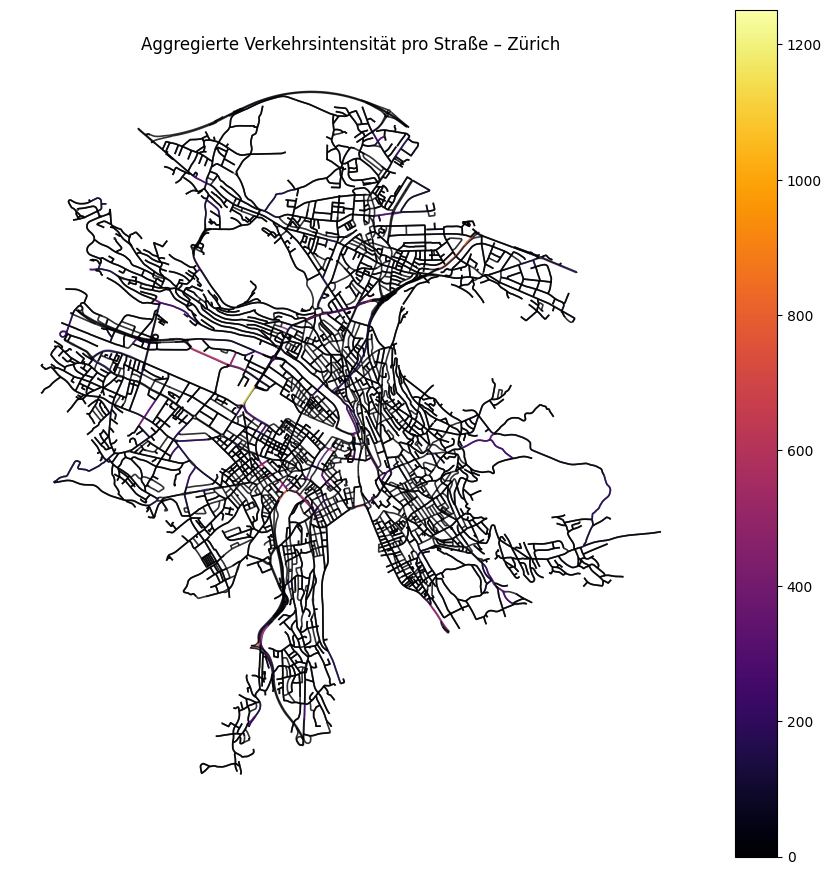

In [123]:
fig, ax = plt.subplots(figsize=(11, 11))
gdf_edges.plot(
    ax=ax,
    linewidth=1.2,
    alpha=0.8,
    column="total_flow",
    cmap="inferno",
    legend=True
)
ax.set_title("Aggregierte Verkehrsintensität pro Straße – Zürich")
ax.set_axis_off()
plt.show()

## Interaktive Karte mit Folium (Heatmap-Variante)

In [99]:
subset = gdf_edges[gdf_edges["total_flow"] > 0]
n = min(4000, len(subset))  # maximal 4000, aber nicht mehr als existieren

for _, row in subset.sample(n, random_state=1).iterrows():
    color = plt.cm.inferno(row["flow_norm"])
    color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    folium.PolyLine(
        locations=[(y, x) for x, y in row["geometry"].coords],
        color=color,
        weight=3.0 * row["flow_norm"] + 0.4,
        opacity=0.8
    ).add_to(m)


m.save("zuerich_flow_heatmap.html")
print("Karte gespeichert als 'zuerich_flow_heatmap.html'")


Karte gespeichert als 'zuerich_flow_heatmap.html'


In [100]:
print(df_edge_flow[["start_node","end_node"]].dtypes)
print(edges_gdf[["u","v"]].dtypes)


start_node    int64
end_node      int64
dtype: object
u    int64
v    int64
dtype: object


In [124]:
m = folium.Map(location=[47.37, 8.54], zoom_start=12, tiles="cartodbpositron")

subset = gdf_edges[gdf_edges["total_flow"] > 0]
n = min(4000, len(subset))

for _, row in subset.sample(n, random_state=1).iterrows():
    color = plt.cm.inferno(row["flow_norm"])
    color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    folium.PolyLine(
        locations=[(y, x) for x, y in row["geometry"].coords],
        color=color,
        weight=3.0 * row["flow_norm"] + 0.4,
        opacity=0.8
    ).add_to(m)

m.save("zuerich_flow_heatmap_fixed.html")
print("Karte gespeichert als 'zuerich_flow_heatmap_fixed.html'")

Karte gespeichert als 'zuerich_flow_heatmap_fixed.html'


In [134]:
print("Propagierte Segmente:", len(df_flows_dir))
print("Min/Mean/Max Distanz (m):", df_flows_dir["distance_m"].min(), df_flows_dir["distance_m"].mean(), df_flows_dir["distance_m"].max())
print("Flussverteilung:")
print(df_flows_dir["flow_value"].describe(percentiles=[.1,.5,.9,.99]))


Propagierte Segmente: 809239
Min/Mean/Max Distanz (m): 4.358655336142953 3132.5271885786465 4999.970570923045
Flussverteilung:
count    809239.000000
mean        104.862862
std         111.301588
min           0.073073
10%          12.493793
50%          69.919806
90%         242.585781
99%         535.040891
max        1331.534306
Name: flow_value, dtype: float64


## räumliches Matching statt topologisches

### 1. Erzeuge Liniengeometrien für deine propagierten Flüsse

In [177]:
from shapely.geometry import LineString, Point
import geopandas as gpd
from tqdm import tqdm

tqdm.pandas()

print("➡️ [1/3] Erzeuge Fluss-Linien aus df_flows_dir ...")

flow_lines = []
for _, row in tqdm(df_flows_dir.iterrows(), total=len(df_flows_dir), desc="Linien erzeugen"):
    try:
        u = row["start_node"]
        v = row["end_node"]

        pu = Point(G.nodes[u]["x"], G.nodes[u]["y"])
        pv = Point(G.nodes[v]["x"], G.nodes[v]["y"])

        flow_lines.append({
            "MSID": row["MSID"],
            "flow_value": row["flow_value"],
            "geometry": LineString([pu, pv])
        })
    except KeyError:
        continue

gdf_flows = gpd.GeoDataFrame(flow_lines, crs="EPSG:4326")

print(f"✅ {len(gdf_flows)} Linien erzeugt.")
print(gdf_flows.head())


➡️ [1/3] Erzeuge Fluss-Linien aus df_flows_dir ...


Linien erzeugen: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809239/809239 [00:36<00:00, 22295.02it/s]


✅ 809239 Linien erzeugt.
       MSID  flow_value                                         geometry
0  Z001M001  162.013252  LINESTRING (8.53559 47.34336, 8.53548 47.34357)
1  Z001M001   23.841351  LINESTRING (8.53559 47.34336, 8.53542 47.34355)
2  Z001M001  203.941417  LINESTRING (8.53559 47.34336, 8.53542 47.34355)
3  Z001M001   78.268323  LINESTRING (8.53559 47.34336, 8.53542 47.34355)
4  Z001M001  106.984813  LINESTRING (8.53559 47.34336, 8.53506 47.34359)


## 2. Räumliches Joinen auf die OSM-Kanten (statt ID-Merge)

In [178]:
from tqdm import tqdm
import numpy as np
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore", message="GeoDataFrame.swapaxes")

print("➡️ [2/3] Führe räumlichen Join zwischen Flüssen und OSM-Kanten durch (mit Fortschritt)...")

# Vorbereitung: Projektion
gdf_flows_m = gdf_flows.to_crs(2056)
edges_gdf_m = edges_gdf.to_crs(2056)

# In Blöcke aufteilen (z. B. 10 000 Flusssegmente pro Block)
batch_size = 10000
batches = np.array_split(gdf_flows_m, len(gdf_flows_m) // batch_size + 1)

results = []
for i, batch in enumerate(tqdm(batches, desc="Räumlicher Join (Blöcke)")):
    joined_part = gpd.sjoin_nearest(
        batch,
        edges_gdf_m,
        how="left",
        distance_col="dist_m",
        max_distance=30
    )
    results.append(joined_part)

# Wieder zusammenführen
joined = pd.concat(results, ignore_index=True)
print(f"✅ Räumlicher Join abgeschlossen – {len(joined)} Zuordnungen erstellt.")
print(joined[["flow_value", "dist_m"]].describe())


➡️ [2/3] Führe räumlichen Join zwischen Flüssen und OSM-Kanten durch (mit Fortschritt)...


/Users/leonarddost/localPythonProjects/CIP/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/leonarddost/localPythonProjects/CIP/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/leonarddost/localPythonProjects/CIP/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
/Users/leonarddost/localPythonProjects/CIP/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and 

✅ Räumlicher Join abgeschlossen – 33327485 Zuordnungen erstellt.
         flow_value      dist_m
count  3.332748e+07  33327485.0
mean   9.900170e+01         0.0
std    1.053326e+02         0.0
min    7.307328e-02         0.0
25%    2.956555e+01         0.0
50%    6.578714e+01         0.0
75%    1.284647e+02         0.0
max    1.331534e+03         0.0


### 3. Aggregation nach OSM-Kante

In [181]:
import pandas as pd
from tqdm import tqdm

tqdm.pandas()

print("➡️ [3/3] Aggregiere Flusswerte pro OSM-Kante ...")

# Aggregation mit Fortschrittsbalken
def aggregate_flow(df):
    return pd.Series({
        "total_flow": df["flow_value"].sum(),
        "n_sources": df["MSID"].nunique()
    })

edges_gdf = edges_gdf.merge(edge_flow, how="left", on=["u", "v", "key"])
edges_gdf["total_flow"] = edges_gdf["total_flow"].fillna(0)
edges_gdf["flow_norm"] = edges_gdf["total_flow"] / edges_gdf["total_flow"].max()

edge_flow = joined.groupby(["u", "v", "key"]).progress_apply(aggregate_flow).reset_index()

print(f"✅ Aggregation abgeschlossen: {len(edge_flow)} Kanten mit Flussdaten.")
print("Kanten mit Flusswerten >", (edges_gdf['total_flow'] > 0).sum(), "von", len(edges_gdf))
print(edges_gdf[["name", "total_flow", "flow_norm"]].head())


➡️ [3/3] Aggregiere Flusswerte pro OSM-Kante ...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10565/10565 [00:13<00:00, 760.84it/s]

✅ Aggregation abgeschlossen: 10565 Kanten mit Flussdaten.
Kanten mit Flusswerten > 10565 von 10566
                name     total_flow  flow_norm
0  Bernerstrasse Süd  711128.029167   0.095977
1   Duttweilerbrücke  197705.272534   0.026683
2        Hohlstrasse  164251.560490   0.022168
3        Hohlstrasse  688609.420887   0.092937
4     Herdernstrasse  384274.650987   0.051863


### Karte visualisieren (Heatmap)

In [182]:
import folium, matplotlib.pyplot as plt
from tqdm import tqdm

print("🗺️ Erzeuge interaktive Heatmap-Karte ...")

m = folium.Map(location=[47.37, 8.54], zoom_start=12, tiles="cartodbpositron")

subset = edges_gdf[edges_gdf["total_flow"] > 0]
n = min(5000, len(subset))

for _, row in tqdm(subset.sample(n, random_state=1).iterrows(), total=n, desc="Kartenlinien"):
    color = plt.cm.inferno(row["flow_norm"])
    color = f"#{int(color[0]*255):02x}{int(color[1]*255):02x}{int(color[2]*255):02x}"
    folium.PolyLine(
        locations=[(y, x) for x, y in row["geometry"].coords],
        color=color,
        weight=2.5 * row["flow_norm"] + 0.4,
        opacity=0.7
    ).add_to(m)

m.save("zuerich_flow_heatmap_final.html")
print("✅ Karte gespeichert als 'zuerich_flow_heatmap_final.html'")


🗺️ Erzeuge interaktive Heatmap-Karte ...


Kartenlinien: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 8318.64it/s]


✅ Karte gespeichert als 'zuerich_flow_heatmap_final.html'


# Datenlage anpassen

## 7-Tages-Durchschnitt pro Messstelle

In [183]:
import pandas as pd
import geopandas as gpd
from pyproj import Transformer

print("➡️ Aggregiere tägliche Summen und 7-Tages-Durchschnitt ...")

# --- 1️⃣ Tagesdatum extrahieren ---
df["Datum"] = df["MessungDatZeit"].dt.date

# --- 2️⃣ Nur gültige Messungen verwenden ---
df_valid = df[df["AnzFahrzeugeStatus"] == "Gemessen"].copy()

# --- 3️⃣ Tages-Summe pro Messstelle ---
daily_sum = (
    df_valid.groupby(["MSID", "Richtung", "Datum"], as_index=False)
    ["AnzFahrzeuge"].sum()
    .rename(columns={"AnzFahrzeuge": "Fahrzeuge_pro_Tag"})
)

# --- 4️⃣ 7-Tages-Mittelwert pro Messstelle ---
weekly_mean = (
    daily_sum.groupby(["MSID", "Richtung"], as_index=False)
    ["Fahrzeuge_pro_Tag"].mean()
    .rename(columns={"Fahrzeuge_pro_Tag": "flow_daymean"})
)

print(f"✅ {len(weekly_mean)} Messstellen mit 7-Tages-Durchschnitt berechnet.")

# --- 5️⃣ Koordinaten transformieren (LV95 → WGS84) ---
transformer = Transformer.from_crs(2056, 4326, always_xy=True)
weekly_mean["lon"], weekly_mean["lat"] = transformer.transform(
    df_valid.groupby("MSID")["EKoord"].first().values,
    df_valid.groupby("MSID")["NKoord"].first().values
)

# --- 6️⃣ GeoDataFrame erzeugen ---
gdf_weekly = gpd.GeoDataFrame(
    weekly_mean,
    geometry=gpd.points_from_xy(weekly_mean["lon"], weekly_mean["lat"]),
    crs="EPSG:4326"
)

print(gdf_weekly.head(5))


➡️ Aggregiere tägliche Summen und 7-Tages-Durchschnitt ...
✅ 212 Messstellen mit 7-Tages-Durchschnitt berechnet.
       MSID  Richtung  flow_daymean       lon        lat  \
0  Z001M001  auswärts   6695.202703  8.537068  47.341059   
1  Z001M002  einwärts   8341.135135  8.537112  47.341071   
2  Z002M001  auswärts   5383.216216  8.529921  47.334167   
3  Z002M002  einwärts   6720.283784  8.529980  47.334165   
4  Z003M001  auswärts   3682.182432  8.517891  47.332547   

                   geometry  
0  POINT (8.53707 47.34106)  
1  POINT (8.53711 47.34107)  
2  POINT (8.52992 47.33417)  
3  POINT (8.52998 47.33417)  
4  POINT (8.51789 47.33255)  


In [184]:
# Ersetze gdf_stations durch die neue, aggregierte Version
gdf_stations = gdf_weekly.copy()

# Umbenennen für Kompatibilität
gdf_stations.rename(columns={"flow_daymean": "flow_mean"}, inplace=True)


In [185]:
# Join mit alten Metadaten (falls du sie noch im Speicher hast)
gdf_stations = gdf_stations.merge(
    old_gdf_stations[["MSID", "Richtung", "Richtung_typ", "bearing_seed"]],
    on="MSID",
    how="left"
)


NameError: name 'old_gdf_stations' is not defined

In [186]:
print("➡️ Erzeuge Seeds mit Tagesdurchschnitts-Flusswerten ...")

seeds = []
for _, row in gdf_stations.iterrows():
    seed = {
        "MSID": row["MSID"],
        "flow_value": row["flow_mean"],  # jetzt Tagesmittel
        "bearing_seed": row["bearing_seed"],
        "geometry": row["geometry"]
    }
    seeds.append(seed)

df_seeds = pd.DataFrame(seeds)
print(f"✅ {len(df_seeds)} Seeds mit Tages-Durchschnittswerten erstellt.")


➡️ Erzeuge Seeds mit Tagesdurchschnitts-Flusswerten ...


KeyError: 'bearing_seed'